[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hbprosper/mlinphysics/blob/main/Labs/04.CNN/tutorial_CNN.ipynb)

# Tutorial: Convolutional Neural Networks (CNN)
> Created: Aug. 2024 for the FSU Course: *Machine Learning in Physics* <br>
> Updated: Sun Sep 20 2025: Adapted for Introduction to ML course at AIMS South Africa<br>
> Updated: Wed Sep 30 2026: Use Hadamard product in my_conv2d; and tidy up<br>
> Harrison B. Prosper<br>


## Introduction

In this tutorial, we try to classify galaxies according to their morphology using the Galaxy10 dataset from [AstroNN](https://astronn.readthedocs.io/en/latest/galaxy10.html), which contains 17,736 RGB (that is, 3-channel) $256\times256$-pixel galaxy images grouped into 10 morphology classes. Of these a subset of 12,600 images grouped into 7 morphology classes of 1,800 images each is used. To reduce the computational burden, each image is cropped to $96\times96$ pixels. Nevertheless, each 3-channel image is described by $96\times96\times 3 = 27,648$ bytes or 3,456 32-bit integers! The model of choice for classifying 2D images is the **convolutional neural network** (CNN), which is the subject of this notebook.

## Model

Here is a high-level view of the model we shall fit,
\begin{align}
\boldsymbol{y}(\boldsymbol{x}) & = \texttt{softmax}(\texttt{linear}(\texttt{flatten} (\texttt{g}_3(\texttt{g}_2(\text{g}_1(\texttt{g}_0(\boldsymbol{x} \,) \,) \, ) \, ) \, )\, )\,) .
\end{align}

The functions **softmax**, **flatten**, and **g** are defined as follows:

  * **softmax** For $K = 7$ output classes,
\begin{align*}
\text{softmax}(x)_k & = \frac{\exp(x_{k})}{\sum_{j=0}^{K-1} \exp(x_{j})} ,
\end{align*}
where $x_{k}$ denotes output $k$ of the linear function.  The
softmax function ensures that the $K$ outputs
sum to unity.

  * **flatten** Given tensor $\boldsymbol{x}$, this function unfolds the tensor into a 1D tensor.

  * **g** Given tensor $\boldsymbol{x}$, this function
  \begin{align}
  \text{g}(\boldsymbol{x}) = \texttt{maxpool}(\texttt{relu}(\texttt{conv2d}(\boldsymbol{x}))),
  \end{align}
convolves $\boldsymbol{x}$, applies the nonlinear function relu to every element of its tensor argument and finally performs a downsampling of the resulting image. The functions
 $\texttt{relu}$, $\texttt{maxpool}$, and $\texttt{conv2d}$ are defined below.

  * **relu** Given tensor $\boldsymbol{x}$, the function
\begin{align*}
\texttt{relu}(x) &= \texttt{max}(0, x)
\end{align*}
is applied
*element-wise*, that is, to every element of its argument.

  * **maxpool** Given tensor $\boldsymbol{x}$, this function uses a moveable window to downsample $\boldsymbol{x}$. In this tutorial, the moveable window  splits the tensor into non-overlapping pieces. For each piece, the maximum pixel value within that piece is returned. For example, if $\boldsymbol{x}$ is a 2D tensor, e.g., a matrix, of shape (96, 96), and the window is of shape (2, 2), maxpool splits the original matrix into $48 \times 48$ non-overlapping pieces of shape (2, 2) and returns the maximum value within each piece, thereby creating a new image of shape (48, 48).

  * **conv2d** Given tensor $\boldsymbol{x}$, this function returns a convolution of $\boldsymbol{x}$. The operation is described in detail below.

A high-level view, especially when represented pictorially, is a good way to understand the structure of a model.  But it is also good to try to understand the details...at least once! As is often true, a detailed mathematical description of a complicated function is made easier using a concrete example.

## Convolution
The input data into the first layer of our model are a batch of $N$ galaxy images $\boldsymbol{x}$ that form a 4-component tensor of shape $(N, C_\text{in}=3, H=96, W=96)$, where $C_\text{in}$ denotes the number of input channels and $H$ and $W$ are the height and width in pxiels of every channel. The output of the $\texttt{conv2d}$ function (implemented in the PyTorch class $\texttt{Conv2d}$) comprises $N$ images, each of $C_\text{out}$ channels. In this example, we have chosen to keep the height and width of the images unchanged. Each channel of an input image is convolved with each of $C_\text{out} \times C_\text{in}$  parameterized **filter**s of shape $(H_F, W_F) = (3, 3)$, indexed by $(n, m)$ where $0 \le n\le C_\text{out}-1$ and $0 \le m \le C_\text{in}-1$.  The collection of $C_\text{out} \times C_\text{in}$ filters, which also form a 4-component tensor,  is referred to as a **kernel**. The size of the first dimension of the kernel ($\mathbb{dim} = 0$) is the number of **output channels**, e.g., $C_\text{out} = 4$, the size of the second dimension is the number of **input channels**, $C_\text{in} = 3$ and the remaining two indices are the height and width of the filters that comprise the kernel.

Unfortunately, the jargon is not consistent across the machine learning literature. What we call a filter is indeed often referred to as a filter, but it is also called a kernel, and what we call a kernel, that is, a stack of one or more filters, often has no specific name attached to it!

Consider an input image $I$ of shape $(H, W) = (5, 7)$ with $C_\text{in}$ channels, and a single filter $w_{n, m}$ indexed by  output and input channel indices $n$ and $m$, respectively, and of shape $(H_F, W_F)$. Given channel $\boldsymbol{I}_m$, of the input image $I$, each filter $w_{n, m}$ creates a single-channel image $i_{n, m}$. The filter is placed initially so that pixel (0, 0)  of the filter $w_{n, m}$ coincides with pixel (0,0) of the input image channel $I_m$ as shown in the figure below.

<img src="https://github.com/hbprosper/mlinphysics/blob/main/Labs/04.CNN/cnn_stride_panel.png?raw=1" width="1000" alt="A 3x3 filter stepping over a 5x7 image of a cross">

Along each row we choose to move the filter with a horizontal **stride** of 2 (that is, a shift of two pixels); down the rows we move the filter with a vertical stride of 1. (Other choices are possible.) The label $(i,j)$ gives the image pixel index of the filter's $(0,0)$ pixel.  Given the choices for the filter size and strides, the nine filter placements are the only ones that fit in the image, and each placement of the filter corresponds to a pixel in the output channel. Therefore, this operation produces a single-channel image $i_{n, m}$ of shape (3, 3). At each position of the filter one computes a **Hadamard product** $h_{n, m} = w_{n, m} \odot I_m $ between the filter and the part of the image shadowed by the filter. A Hadamard product is simply a matrix element by matrix element multiplication of two matrices (or tensors), which requires the two matrices (or tensors) to be of the same shape. (This, of course, is not the usual matrix multiplication!) The matrix elements of the Hadamard product $h_{n, m}$ are summed thereby producing the value of a pixel of the single-channel image $I_{n, m}$. The computation is repeated for all placements of the filter to complete $I_{n, m}$.

> To summarize: each input channel $I_m$ is processed with $C_\text{out}$ different filters $w_{n, m}$, with $n = 0,\cdots, C_\text{out}-1$, thereby creating $C_\text{out}$ image channels.

The procedure, when applied to all $C_\text{in}$ input channels, generates an intermediate image with $C_\text{out} \times C_\text{in}$ channels from $C_\text{out} \times C_\text{in}$ independent filters, each with its own set of trainable matrix elements. Finally, each channel, $O_n$, of the output image $O$ is computed by summing over the input channel index $m$
\begin{align}
    O_n & = b_n + \sum_{m} I_{n, m},
\end{align}
where, by default, an output channel-dependent bias $b_n$ is added (through broadcasting) to every pixel.

The procedure above produces an output image smaller than the input image, though with a channel count $C_\text{out}$ that may differ from the channel count $C_\text{in}$ of the input image.  Suppose, however, we want to maintain the size of the images, as we do in this tutorial. For the above computations to yield the desired outcome, we surround each image with strips of pixels and use strides of one in both directions. The addition of strips of pixels is called **padding**. Since our filter shape is $(3, 3)$, we pad every image with a single strip of pixels (by default, with value zero). This padding makes it possible to center each of the filters (of shape $(3, 3)$) on every pixel, $(i, j)$, of the unpadded input channels.

In our application, every channel of the input image is a $(96, 96)$ matrix padded with a 1-pixel strip around its boundary, and each of the filters is a $(3, 3)$ matrix. For the first layer of the model, for which we've chosen $C_\text{out} = 4$,
the output of the convolution operation will be a tensor of shape $(N, 4, 96, 96)$ provided that we use a stride of 1. We choose to pad images at every layer of the model. Other choices are possible.

### Down-sampling
A convolutional layer is often followed by a down-sampling, that is, coarse graining, layer that reduces the number of pixels per image. In this tutorial, the number of pixels in the image created by the convolutional layer is reduced by a factor 2 in both directions; that is, each of the 4 channels of the $(96, 96)$-pixel image is down-sampled to a $(48, 48)$-pixel channel by replacing the corresponding group of pixels of shape $(2, 2)$ with a pixel whose value is set to the largest value among the group of 4 pixels and using a stride of 2 horizontally and vertically so that the $2\times 2$ windows are nonoverlapping. This operation is called **max pooling**.
Again, other choices are possible.

After the down-sampling operation, the output tensor has shape $(N, 4, 48, 48)$. A relu nonlinearity is applied to each element of this tensor and completes one sequence of operations: convolution, down-sampling, and nonlinear activation.
This sequence is repeated until we reach the final layer. The input to the final layer is $N$, 7-channel, $6\times6$-pixel images. Each image is flattened to a 1D tensor  of size $7 \times 6 \times 6 = 252$, which is the input to a linear layer with 7 outputs. Finally, a softmax function is applied to normalize the sum of the outputs to one.

## Number of parameters
Our model consists of a sequence of 4 triplets ($\texttt{Conv2d}$, $\texttt{ReLU}$, $\texttt{MaxPool2d}$) of operations. The 4 $\texttt{Conv2d}$ operations have kernels with input and output channel counts $(3, 4), (4, 5), (5, 6)$, and $(6, 7)$, respectively. The same stride and padding is used for every $\texttt{Conv2d}$ operation and the same pooling operation, as described above, is used for every layer. The number of parameters per $\texttt{Conv2d}$ operation is given by $C_\text{out} (1 + C_\text{in} H_F W_F)$.
The number of parameters in a linear layer with $N_\text{in}$ inputs and $N_{out}$ outputs plus a bias parameter for each output is given by $N_\text{out}(1 + N_\text{in})$. From these expressions one can compute the total number of trainable parameters, that is, the dimensionality of the *empirical risk landscape* (average loss) that we need to navigate to find a good minimum.

## Discussion
The net effect of the sequence of nested layers, prior to flattening, is to transform each 3-channel, $(96, 96)$ input image into a 7-channel (6, 6) output image. The hope is that the output image captures the most relevant features of the input image thereby improving the accuracy of the subsequent classification. But why use convolution?

The intuition behind the convolution operation is that images tend to have similar features in different parts of the image. A filter that is sensitive to vertical features would tend to produce an output image that enhances vertical features, while suppressing the expression of horizontal features. It therefore seems plausible that if one could design filters that are sensitive to different image features, the set of filters could potentially transform an image into another in which the most relevant features are enhanced while the least relevant are suppressed.

In the early days of image recognition systems, researchers tried to describe in software what they considered to be the most relevant features in images. This proved to be extremely difficult and success was limited. Today hand coding is no longer necessary because the values of the parameters of the kernels can be determined automatically by minimizing an appropriate (average) loss function. However, the mere fact that a large number of images is needed to fit these parameters is evidence that current machine learning methods and models, while spectacularly successful, are still far removed from the internal models humans use to learn about the world.

A young child need be shown labeled objects, cat, dog, doll, truck, car, just a few times before being able to classify them correctly. The child can do this even when the objects are presented to her in orientations that differ from the ones used during the "training phase". This extraordinary ability suggests that the child's brain constructs a fault-tolerant model of each object using only its most relevant features and is able to match rapidly the input image with the stored, or more likely auto-reconstructed, fault-tolerant model. The model is clearly fault tolerant because the child is able to ignore "faults" such as viewing the objects in lighting that differs from that used during the "training phase", or ignoring the fact that now the car has lost a couple of wheels or the doll is now wearing different clothes.

Despite the truly impressive successes of machine learning, and artificial intelligence more broadly, it is clear that machine learning-based AI still has a long way to go before AI can fully replicate, or go beyond, the full breadth of human cognition. But, perhaps, it could be that the age-old goal of building machines that think like humans is simply the wrong goal. After all, there are already many instances in which researchers have inadvertently succeeded in producing machines that mimic our prejudices, which is hardly progress. Therefore, perhaps we should embrace the "artificial" in artificial intelligence and the likely reality that these alien minds will inevitably think differently from us. The trick, of course, is to have them think in a way that improves the human condition.

## Running on Google Colab
If on Google Colab (https://colab.research.google.com), execute cell below.

In [1]:
try:
    import google.colab

    REPO = "hbprosper/mlinphysics"

    url  = f"https://raw.githubusercontent.com/{REPO}/refs/heads/main"
    !wget -q {url}/clone2colab.ipynb -O clone2colab.ipynb
    %run clone2colab.ipynb

    IN_COLAB = True

except ImportError:

    IN_COLAB = False

/content
	1. uninstall mlinphysics
	2. sparse clone mlinphysics

/content/mlinphysics
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 5 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (5/5), 13.07 KiB | 3.27 MiB/s, done.

	3. install mlinphysics

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
/content


In [2]:
# standard system modules
import os, sys

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn
import torch.utils.data as dt
print('torch version:', torch.__version__)

# module to access data in Hierarchical Data Format (HDF or H5 format)
import h5py

# module to plot pixelized images
import imageio.v3 as im

# module to reimport Python modules
import importlib

# module for shell utilities
import shutil

# ML in physics module
import drwho.nn as mlp
import drwho.data as dat
import drwho.monitor as mon

plt.rcParams.update({
  "text.usetex": shutil.which('latex') is not None,
  "font.family": "sans-serif",
  "font.size": 14
})

torch version: 2.11.0+cu130


## Set Computational Device

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n\tAvailable device: {str(DEVICE):4s}\n')


	Available device: cuda



# PART 1

## Convolution Exercise
Let $y = f * g$ be the convolution of the functions $f(x)$ and $g(x)$. By definition,

$y(t)  = \int f(\tau) \, g(t-\tau) \, d\tau .$

In the exercise below, we compute the convolution of a 1-channel image using $\texttt{Conv2d}$ and using an explicit calculation.

### Create a 1-channel $5 \times 5$-pixel image

image.shape: (1, 5, 5)


array([[0.4, 0.3, 0.8, 0.3, 0.4],
       [0.3, 0.2, 0.9, 0.2, 0.3],
       [0.7, 0.9, 1. , 0.9, 0.7],
       [0.3, 0.2, 0.9, 0.2, 0.3],
       [0.4, 0.3, 0.5, 0.3, 0.4]], dtype=float32)

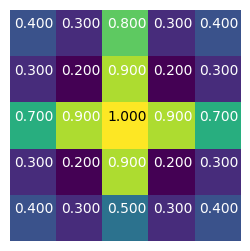

In [4]:
image = np.array([[0.4,0.3,0.8,0.3,0.4],
                  [0.3,0.2,0.9,0.2,0.3],
                  [0.7,0.9,1.0,0.9,0.7],
                  [0.3,0.2,0.9,0.2,0.3],
                  [0.4,0.3,0.5,0.3,0.4]]).reshape(1,5,5).astype(np.float32)

print('image.shape:', image.shape)

def plot_image(image, fgsize=(3, 3), filename='image.png'):

    image = image.transpose(1, 2, 0) # (C, H, W) => (H, W, C)
    H, W, C = image.shape

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=fgsize)

    ax.set_xticks(np.arange(0, W, 1))
    ax.set_yticks(np.arange(0, H, 1))
    ax.imshow(image, extent=(0, W, H, 0))
    ax.grid()

    ii = H // 2
    dx = 0.1
    dy = 0.4
    for i in range(H):
        for j in range(W):
            z = image[i, j, 0]
            x = j + dx
            y = i + dy
            if i == ii and j == ii:
                c = 'black'
            else:
                c = 'white'
            ax.text(x, y, f'{z:5.3f}', color=c, fontsize=10)
    ax.axis('off')
    #fig.tight_layout()
    plt.savefig(filename)

figsize = np.array([3, 3])
plot_image(image, fgsize=figsize, filename='input_image.png')

image[0,:,:]

### Compute convolution using `Conv2d`
  * $C_{in} = 1$ input channel, $C_{out} = 3$ output channels
  * kernel with filters of shape $(3, 3)$
  * stride of 1 pixel
  * padding of 0 pixels

Conv2d parameters
  weight.shape: (3, 1, 3, 3)
  bias.shape  : (3,)

input_image.shape : torch.Size([1, 1, 5, 5])
output_image.shape: torch.Size([3, 3, 3])

display_image.shape (3, 3, 3)


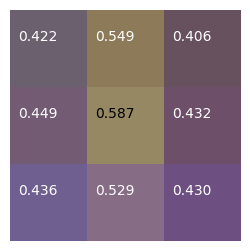

In [7]:
C_in   = 1
C_out  = 3
H_F    = 3
W_F    = 3
STRIDE = 1
PADDING = 0

conv2d = nn.Conv2d(in_channels=C_in,
                   out_channels=C_out,
                   kernel_size=(H_F, W_F),
                   stride=STRIDE,
                   padding=PADDING)

# get weights (after detaching from computation tree)
weight = conv2d.state_dict()['weight'].detach().cpu().numpy()
print('Conv2d parameters')
print('  weight.shape:', weight.shape)

# get biases
bias = conv2d.state_dict()['bias'].detach().cpu().numpy()
print('  bias.shape  :', bias.shape)
print()

# convert image to a float32 tensor of shape  (N, C_in, H, W)
# (Note: the type is inherited from the numpy array, "image")
C_in, H, W  = image.shape
input_image = torch.tensor(image).view(1, C_in, H, W)
print('input_image.shape :', input_image.shape)

# convolve image and squeeze away dim=0
output_image = conv2d(input_image).squeeze() # shape (C_out, H, W)
print('output_image.shape:', output_image.shape)
print()

# map pixel values of convolved image to [0, 1] and dislay image
sigmoid = nn.Sigmoid()
display_image = sigmoid(output_image).detach().cpu().numpy()
print('display_image.shape', display_image.shape)

plot_image(display_image, filename='convolved_image.png')

### Compute convolution by hand: `mu_conv2d`
  1. `pad_image` - example of a function to pad an image
  2. `my_conv2d` - example of a function to convolve an image

padded image: (1, 7, 7)


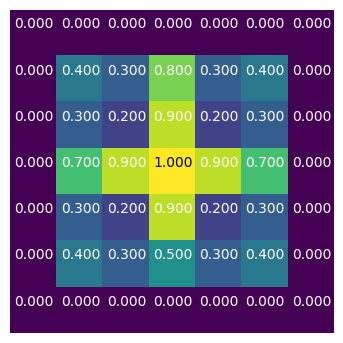

In [8]:
def pad_image(image, padding=1):
    C, H, W = image.shape

    # pad vertically
    padding_t = np.zeros(H*padding).reshape(1, H, padding)
    image     = np.concatenate((padding_t, image, padding_t), axis=2)

    # pad horizontally
    padding_t = np.zeros(padding*(W+2*padding)).reshape(1, padding, W+2*padding)
    image     = np.concatenate((padding_t, image, padding_t), axis=1)

    return image

padded_image = pad_image(image, padding=1)
print('padded image:', padded_image.shape)

# plot padded image
C, H, W = image.shape
figsize2 = figsize * (H+2)/H
plot_image(padded_image, fgsize=figsize2, filename='padded_image.png')

Work through each of the code fragments in the cell below and add additional comments demonstrating your understanding of each fragment. These code fragments are used in `my_conv2d`.

In [ ]:
kernel_size = 3
print(f'kernel size: {kernel_size}x{kernel_size}')

# -------------------------------------------------------------------
# 1. get input image size
# -------------------------------------------------------------------
c_in, height, width = image.shape
print('input image shape', image.shape)
print(image)
print()

# -------------------------------------------------------------------
# 2. determine where in the input image to start and end the
# placement of the center of the filters assuming a stride of 1
# -------------------------------------------------------------------
pixel_start = np.floor(kernel_size/2).astype(int)  # first pixel index
pixel_end   = width - pixel_start - 1              # last pixel index
print('start and end pixels:', pixel_start, pixel_end)
print()

# -------------------------------------------------------------------
# 3. construct filter indices so that (0, 0) is the center of the
# filter (that's why we want odd-sized filters!)
# -------------------------------------------------------------------
filter_end   = kernel_size // 2
filter_start =-filter_end
print('filter index bounds:', filter_start, filter_end)
print()

# -------------------------------------------------------------------
# 4. extract sub image and compute a Hadamard product between the
# filter and sub image
# -------------------------------------------------------------------
n = 0                                  # choose output channel index
m = 0                                  # choose input channel index
ii, jj = pixel_start, pixel_start + 1  # choose input pixel (ii, jj)

# for input channel "m", extract sub-image equal in size to the filter
sub_image = image[m,
    ii+filter_start:ii+filter_end+1,
    jj+filter_start:jj+filter_end+1]
print(f'sub image of shape {sub_image.shape} centered '\
      f'at pixel (row, column): ({ii},{jj})')
print(sub_image)
print()

# -------------------------------------------------------------------
# 5. compute a Hadamard product between the filter and sub image
# -------------------------------------------------------------------
print('Hadamard product between filter and sub image')
had_prod = weight[n, m] * sub_image
print(had_prod)
print()

# -------------------------------------------------------------------
# 6. the output pixel value at (i, j) for given output and input
# channels (n, m) is the sum of the matrix elements of the
# Hadamard product
# -------------------------------------------------------------------
i = ii - pixel_start
j = jj - pixel_start
print(f'output pixel value ({i},{j}): {had_prod.sum():10.4f}')

kernel size: 3x3
input image shape (1, 5, 5)
[[[0.4 0.3 0.8 0.3 0.4]
  [0.3 0.2 0.9 0.2 0.3]
  [0.7 0.9 1.  0.9 0.7]
  [0.3 0.2 0.9 0.2 0.3]
  [0.4 0.3 0.5 0.3 0.4]]]

start and end pixels: 1 3

filter index bounds: -1 1

sub image of shape (3, 3) centered at pixel (row, column): (1,2)
[[0.3 0.8 0.3]
 [0.2 0.9 0.2]
 [0.9 1.  0.9]]

Hadamard product between filter and sub image
[[ 0.02389986  0.15213573  0.06602447]
 [ 0.02875691 -0.00521997 -0.03678608]
 [-0.05784481 -0.09168844 -0.08569844]]

output pixel value (0,1):    -0.0064


In [ ]:
def my_conv2d(image, c_out, W, B, kernel_size=3, padding=1, debug=False):
    '''
    image:         image of shape (channels, height, width)
    c_out:         number of output channels
    W, B:          weights and biases from Conv2d
    kernel_size:   must be an odd integer [3]
    padding:       width of padding in pixels [1]

    Assume a stride of 1.
    '''

    # require kernel sizes to be odd
    if kernel_size == 2*(kernel_size // 2):
        raise ValueError('kernel size must be odd so that its center is (0,0).')

    # -------------------------------------------------------------------
    # 1. get input image size after optional padding
    # -------------------------------------------------------------------
    p_image = pad_image(image, padding)
    c_in, height, width = p_image.shape
    if debug:
        print(f'input image shape (after optional padding): {p_image.shape}')

    # -------------------------------------------------------------------
    # 2. determine where in the input image to start and end the
    # placement of the center of the filters assuming a stride of 1
    # -------------------------------------------------------------------
    pixel_start = np.floor(kernel_size/2).astype(int)  # first pixel index
    pixel_end   = width - pixel_start - 1              # last pixel index
    if debug:
        print('start and end pixels:', pixel_start, pixel_end)

    # height and width of output images (we assume square images)
    o_height = pixel_end - pixel_start + 1
    o_width  = o_height

    # reserve storage for output image
    o_image = np.zeros(c_out * o_height * o_width).reshape(
        c_out, o_height, o_width)
    if debug:
        print(c_out)
        print(f'output image shape: {o_image.shape}')
        print()

    # -------------------------------------------------------------------
    # 3. construct filter indices so that (0, 0) is the center of the
    # filter (that's why we want odd-sized filters!)
    # -------------------------------------------------------------------
    filter_end   = kernel_size // 2
    filter_start =-filter_end
    if debug:
        print('filter index bounds:', filter_start, filter_end)
        print()

    # -------------------------------------------------------------------
    # loop over input channels
    # -------------------------------------------------------------------
    for m in range(c_in):

        Y = [] # list to accumulate the c_out channels of the output image

        # loop over output channels
        for n in range(c_out):

            # bias (one number per output channel)
            b = B[n]

            # create bias matrix
            Y.append(np.array([[b] * o_width] * o_height))

            # loop over pixels (i, j) of input image
            # and map to pixel (ii, jj) of output image
            for i in range(pixel_start, pixel_end+1):
                # output image pixel index starts at zero
                ii = i - pixel_start

                for j in range(pixel_start, pixel_end+1):
                    # output image pixel index starts at zero
                    jj = j - pixel_start

                    # for input channel "m", extract sub-image equal
                    # in size to the filter
                    sub_image = p_image[m,
                        i+filter_start:i+filter_end+1,
                        j+filter_start:j+filter_end+1]

                    # for output channel "n", compute Hadamard product
                    # between filter and sub image of channel "m" of
                    # the input image, then sum the matrix elements
                    # to obtain the value of output pixel (ii, jj)
                    had_prod = W[n, m] * sub_image
                    Y[n][ii, jj] += had_prod.sum()

        # now sum pixel-by-pixel over the input channels
        o_image += np.array(Y)

    return o_image

print('Conv2d')
o_image_conv2d   = output_image.detach().cpu().numpy()
print(o_image_conv2d)
print()

print('my_conv2d')
o_image_myconv2d = my_conv2d(
    image, C_out, weight, bias, kernel_size=3, padding=0)
print(o_image_myconv2d)

Conv2d
[[[-0.3432717  -0.26838264 -0.19352438]
  [-0.21377356 -0.18720895 -0.1811392 ]
  [-0.03934884  0.09103963  0.11825031]]

 [[ 0.50521606  0.85471904  0.803887  ]
  [ 0.52631414  1.0193377   0.86389565]
  [ 0.19102727  0.41876313  0.41523883]]

 [[-0.24730772 -0.41078055 -0.29181784]
  [-0.01231354 -0.12838863  0.02378829]
  [-0.09134468 -0.16669792 -0.13211232]]]

my_conv2d
[[[-0.3432717  -0.26838264 -0.19352436]
  [-0.21377358 -0.18720892 -0.18113922]
  [-0.03934885  0.09103962  0.11825034]]

 [[ 0.50521606  0.85471904  0.80388707]
  [ 0.52631414  1.01933753  0.86389565]
  [ 0.19102728  0.41876313  0.41523883]]

 [[-0.24730773 -0.41078058 -0.29181787]
  [-0.01231355 -0.12838864  0.02378829]
  [-0.09134465 -0.16669793 -0.13211231]]]


# PART 2 - TRAINING

## Load Galaxy Images
Load galaxy images and normalize pixels by dividing each by 256.

In [9]:
importlib.reload(dat)

def load_images(filename='data/galaxy10.h5'):
    with h5py.File(filename, 'r') as F:
        images = np.array(F['images']) / 256 # normalize pixels
        images = images.astype(np.float32)
        labels = np.array(F['labels'])       # class labels, k = 0 to 6
    return images, labels

def plot_images(images, targets,
                n_rows=4,
                n_cols=5):

    f_size = (6, n_rows * 1.3)

    fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=f_size)

    # note use of flatten() to convert the matrix
    # of shape (nrows, ncols) to a 1-d array.
    axs = axs.flatten()
    n = len(axs)

    # use "zip" to create an list of shape (N, 3)
    for image, target, ax in zip(images[:n], targets[:n], axs):

        ax.axis('off')

        ax.imshow(image)

        # Note: (x, y) coordinates are in pixels,
        # where (0, 0) is the upper left corner
        ax.text(8, 16, f'{target:d}', color='white')

    plt.savefig('galaxy_images.png')

✅ Download succeeded.
number of images: 12600


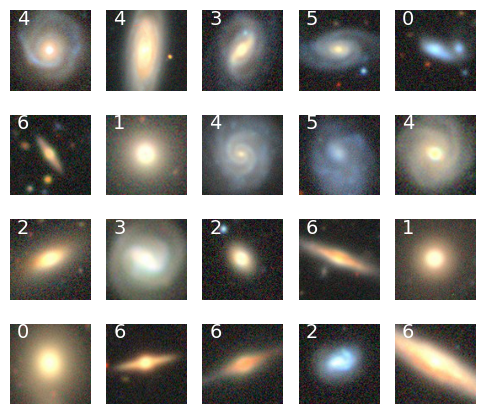

In [10]:
datafile = 'data/galaxy10.h5'

if dat.download(datafile):

    images, targets = load_images()

    print(f'number of images: {len(images):d}')

    plot_images(images, targets)

else:
    raise RuntimeError(f'''
    Download of file {datafile} failed!
    ''')

## Configuration

In [15]:
# name of model
# -----------------------------------------
name = 'galaxy'

# create new configuration
config = mlp.Config(name, dirname='CNN')

# training configuration
# -----------------------------------------
n_images   = len(images)
batch_size = 256
train_size = 10_000
val_size   =    600
test_size  = n_images - train_size - val_size

config('batch_size', batch_size)
config('train_size', train_size)           # set training sample size
config('test_size',  test_size)            # set test sample size
config('val_size',   val_size)             # set validation sample size

config('monitor_step', 100)   # set monitor training every "n" iterations
config('delete', True)        # delete losses file before training, if True
config('frac', 0.015)         # save model if average loss decreases by more
                              # than frac percent

# optimizer / scheduler configuration
# -----------------------------------------
# a step comprises a given number of iterations
config('n_iterations', 100_000)

config('n_steps', 4)          # number of training steps
config('n_iters_per_step', config('n_iterations') // config('n_steps'))

config('base_lr', 1.e-3)      # initial learning rate
config('gamma', 0.8)          # learning rate scale factor

print(f'\nSave configuration to file {config('file/config')}\n')
config.save()

print(config)


Save configuration to file runs/CNN/galaxy_config.yaml

name: galaxy
file:
  losses: runs/CNN/galaxy_losses.csv
  params: runs/CNN/galaxy_params.pth
  init_params: runs/CNN/galaxy_init_params.pth
  plots: runs/CNN/galaxy_plots.png
  config: runs/CNN/galaxy_config.yaml
batch_size: 256
train_size: 10000
test_size: 2000
val_size: 600
monitor_step: 100
delete: true
frac: 0.015
n_iterations: 100000
n_steps: 4
n_iters_per_step: 25000
base_lr: 0.001
gamma: 0.8



## Prepare Datasets and DataLoaders
  1. Split data into training, testing, and validation sets.
  2. Change shape of tensors to from $(N, H, W, C)$ to $(N, C, H, W)$.
  3. Move them to computational device.

In [16]:
print(images.shape)

t_images = images.transpose(0, 3, 1, 2)

print(t_images.shape)

(12600, 96, 96, 3)
(12600, 3, 96, 96)


### Datasets

In [17]:
importlib.reload(dat)

train_size = config('train_size')
val_size   = config('val_size')
test_size  = config('test_size')

# training dataset (this defines the empirical risk to be minimized)
print('training data')
train_data = dat.Dataset(t_images,
                         start=0,
                         end=train_size,
                         targets=targets)

# a random subset of the training data to check for overtraining
# by comparing with the empirical risk from the validation set
print('training data for validation')
train_data_val = dat.Dataset(t_images,
                             start=0,
                             end=train_size,
                             targets=targets,
                             random_sample_size=val_size)


# validation dataset (for monitoring training)
print('validation data')
val_data = dat.Dataset(t_images,
                       start=train_size,
                       end=train_size + val_size,
                       targets=targets)

# test dataset
print('test data')
test_data= dat.Dataset(t_images,
                       start=train_size + val_size,
                       end=train_size + val_size + test_size,
                       targets=targets)

training data
Dataset
  shape of x: torch.Size([10000, 3, 96, 96])
  shape of y: torch.Size([10000])

training data for validation
Dataset
  shape of x: torch.Size([600, 3, 96, 96])
  shape of y: torch.Size([600])

validation data
Dataset
  shape of x: torch.Size([600, 3, 96, 96])
  shape of y: torch.Size([600])

test data
Dataset
  shape of x: torch.Size([2000, 3, 96, 96])
  shape of y: torch.Size([2000])



### DataLoaders

In [18]:
print('train data loader')
train_loader = dat.DataLoader(train_data,
                              batch_size=config('batch_size'),
                              num_iterations=config('n_iterations'),
                              shuffle=True)


print('train data loader for validation')
train_loader_val = dat.DataLoader(train_data_val,
                                  batch_size=len(train_data_val))

print('validation data loader')
val_loader  = dat.DataLoader(val_data,
                             batch_size=len(val_data))

print('test data loader')
test_loader = dat.DataLoader(test_data,
                             batch_size=len(test_data))

X, Y = next(iter(train_loader))
X.shape, Y.shape

train data loader
DataLoader
  Number of iterations has been specified
  maxiter:          100000
  batch_size:          256
  shuffle_step:         39

train data loader for validation
DataLoader
  maxiter:               1
  batch_size:          600
  shuffle_step:          1

validation data loader
DataLoader
  maxiter:               1
  batch_size:          600
  shuffle_step:          1

test data loader
DataLoader
  maxiter:               1
  batch_size:         2000
  shuffle_step:          1



(torch.Size([256, 3, 96, 96]), torch.Size([256]))

Time data loaders

In [19]:
# PyTorch data loader
loader1 = dt.DataLoader(train_data,
                        batch_size=config('batch_size'),
                        shuffle=True)

# mlinphysics data loader
loader2 = dat.DataLoader(train_data,
                         batch_size=config('batch_size'),
                         num_iterations=len(loader1),
                         shuffle=True)

DataLoader
  Number of iterations has been specified
  maxiter:              40
  batch_size:          256
  shuffle_step:         39



In [20]:
%%timeit -r 5 -n 5
for n, (x, y) in enumerate(loader1):
    pass

130 ms ± 43.6 ms per loop (mean ± std. dev. of 5 runs, 5 loops each)


In [21]:
%%timeit -r 5 -n 5
for n, (x, y) in enumerate(loader2):
    pass

12.2 ms ± 373 µs per loop (mean ± std. dev. of 5 runs, 5 loops each)


## Build model

In [23]:
class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels, padding=1, dropout=0.2):

        super().__init__()

        kernel_size = 2*padding + 1

        self.conv1 = nn.Conv2d(in_channels=in_channels,
                               out_channels=out_channels,
                               kernel_size=kernel_size,
                               stride=1,
                               padding=padding)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.maxpool = nn.MaxPool2d(kernel_size=(2, 2), stride=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.maxpool(x)
        return x

class GalaxyClassifier(mlp.Model):

    def __init__(self, image_size=96, channels=[3, 4, 5, 6, 7], padding=1):
        super().__init__()

        # number of convolutional layers
        nlayers = len(channels)-1

        # number of inputs into classification layer
        final_image_size = int(image_size /  2**nlayers)
        ninputs = channels[-1] * final_image_size**2

        self.net = nn.Sequential()
        for i in range(nlayers):
            self.net.append( ConvBlock(channels[i], channels[i+1], padding) )
        self.net.append(nn.Flatten())
        self.net.append(nn.Linear(ninputs, 7))
        self.net.append(nn.Softmax(dim=1))

    def forward(self, x):
        return self.net(x)

## Cross Entropy Loss

For a given input $x$, the **cross entropy** is defined by

\begin{align}
\quad H(p, f) &= -\sum_k p_k \log f_k ,
\end{align}

and the **entropy** by

\begin{align}
\quad H(p) = -\sum_i p_i \log p_i .
\end{align}

A related quantity is the **Kullback-Leibler divergence**

\begin{align}
D(p\,\lvert\rvert\,f) &= \sum_i p_i \log(p_i/f_i), \nonumber\\
           &= -\sum_i p_i \log f_i - \left[-\sum_i p_i \log p_i \right],\nonumber\\
           &= H(p, f) - H(p) .
\end{align}


The cross entropy is minimized when the estimated
probabilities $f_i$ match the true probabilities $p_i$, that is, when the
 cross entropy equals the entropy.

### Calculation of average cross entropy loss

  1. For every image $x_i$ the cross entropy loss is $L_i = -\log f_{k_i}$, where $k_i \in [0,\cdots, K-1]$.
  2. For every image in the batch of images, one picks the classifier output, $f_{k_i}$,
        corresponding to the image's known class index, $k_i$.
  3. And one averages over the losses $L_i$ of all images in the batch.


## Instantiate training objects
  1. `model`
  1. `optimizer`
  1. `objective`
  1. `scheduler`
  1. `monitor`

In [24]:
importlib.reload(mon)
importlib.reload(mlp)

# 1.
model = GalaxyClassifier().to(DEVICE)
print(model)
print('number of parameters:', mlp.number_of_parameters(model))
print()

# 2.
optimizer = torch.optim.Adam(
    model.parameters(), lr=config('base_lr'))

# 3.
objective = mlp.Objective(
    model, nn.CrossEntropyLoss()).to(DEVICE)

# 4.
scheduler = mlp.LRStepScheduler(
    optimizer,
    n_steps=config('n_steps'),
    n_iters_per_step=config('n_iters_per_step'),
    base_lr=config('base_lr'),
    gamma=config('gamma')
)

# 5. instantiate object that saves average losses to
# a csv file for realtime monitoring
monitor = mon.Monitor(
    config('n_iterations'),
    config('file/losses'),
    monitorstep=config('monitor_step'),
    newlossfile=True,
    frac=config('frac'),
    model=model,
    paramsfile=config('file/params'))

GalaxyClassifier(
  (net): Sequential(
    (0): ConvBlock(
      (conv1): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (maxpool): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ConvBlock(
      (conv1): Conv2d(4, 5, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (maxpool): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): ConvBlock(
      (conv1): Conv2d(5, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (maxpool): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): ConvBlock(
      (conv1): Conv2d(6, 7, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
      (dropout): Dropout(p=0.2,

In [ ]:
def accuracy(outputs, targets):
    # For each image, return its predicted class label using argmax.
    #
    # argmax scans the numpy along the specified axis, here the
    # horizontal axis, which is in the class direction, and returns the
    # ordinal value of the maximum value, which is the predicted class.
    # Note: outputs must be converted from a tensor to a numpy array
    # before being passed to argmax. axis=1 is to numpy what dim=1 is
    # to PyTorch.
    outputs = np.argmax(outputs.data.cpu().numpy(), axis=1)

    # count how often the predicted class matches the actual class and
    # compute the fraction of correct predictions.
    # Note: targets must be converted to a numpy array for the
    # comparison to work since outputs is a numpy array.
    return float(np.mean(outputs==targets.data.cpu().numpy()))

## Define trainer

In [ ]:
def train(objective, optimizer, scheduler, monitor,
          train_loader, train_small_loader, val_loader):

    for x, y in train_loader:

        # set mode to training so that training-specific
        # operations such as dropout, etc., are enabled.
        objective.train()

        # clear all gradients
        optimizer.zero_grad()

        # compute empirical risk
        R = objective(x, y)

        # compute gradients
        R.backward()

        # take one step downhill in the empirical risk landscape
        optimizer.step()

        # check whether to update learning rate
        scheduler.step()

        # I'm alive printout
        if monitor.step():

            # compute average losses on training and validation data
            t_loss = mlp.compute_avg_loss(objective, train_small_loader)
            v_loss = mlp.compute_avg_loss(objective, val_loader)

            # return current learning rate
            lr = scheduler.lr()

            # update loss file
            monitor(t_loss, v_loss, lr)

In [ ]:
TRAIN = True

if TRAIN:

    monitor.start()

    train(objective, optimizer, scheduler, monitor,
          train_loader, train_loader_val, val_loader)

    monitor.terminate(5)

monlosses runs/CNN/galaxy_losses.csv

		learning rate:  1.000e-03
       100|  0.10%|00:00:23|06:32:50|   4.2 it/s|1.894e+00|1.887e+00|       100|

## Compute accuracy on test set

In [ ]:
model.load(config('file/params'))

test_x, test_y = next(iter(test_loader))

y_pred = model(test_x)

acc = accuracy(y_pred, test_y)

print('\nPercentage of correct predictions: %8.1f%s' % (100*acc, '%'))


Percentage of correct predictions:     63.3%


## Plot Confusion Matrix

In [ ]:
def plot_confusion_matrix(y_pred, y,
                          t=0.5,
                          gfile='confusion_matrix.png'):

    from sklearn.metrics import confusion_matrix

    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_true=y, y_pred=y_pred)

    # Print the confusion matrix using Matplotlib
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.matshow(conf_matrix, cmap=plt.cm.rainbow, alpha=0.8)

    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            ax.text(x=j, y=i, s=conf_matrix[i, j],
                    va='center', ha='center', size='x-large')

    plt.xlabel('Predicted Labels', fontsize=16)
    plt.ylabel('True Labels', fontsize=16)
    plt.title(f'Confusion Matrix', fontsize=16)
    fig.tight_layout()

    plt.savefig(gfile)
    plt.show()

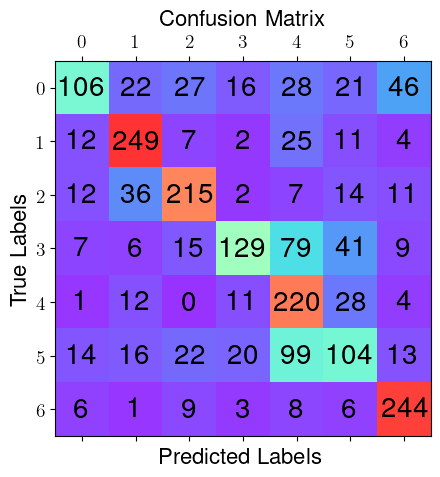

In [ ]:
y_hat  = np.argmax(y_pred.data.cpu().numpy(), axis=1)

y_true = test_y.data.cpu().numpy()

plot_confusion_matrix(y_hat, y_true)